<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 1. Laboratorio: Árboles de decisión, reglas y ensemble learning</header1></left>

Presentado por: Nombres Apellidos  <br>
Fecha: DD/MM/2022

## Importación de librerias necesarias

In [23]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd

# Librerías para los modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Librerías para gráficas
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


## Cargar el Dataset

In [24]:
#Código para cargar el Dataset
url = 'https://raw.githubusercontent.com/oscar-unir/TIA/main/datasets/car/Laboratorio_dataset_car.csv'

try:
    df = pd.read_csv(url, sep=';')
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    # Si no se puede cargar el dataset desde la URL, se carga desde el archivo local debe estar en el mismo directorio raiz
    df = pd.read_csv('Laboratorio_dataset_car.csv',sep=';')

df.head()


,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## Explique el problema a resolver. 
Descripción del problema. Tipo de problema (justifique). Variable objetivo, variables de entrada. Utilidad de su posible solución. Elementos adicionales que considere relevantes: 


Predecir si un coche es aceptable o no según sus características. Es un problema de clasificación supervisada porque cada instancia tiene una etiqueta de clase conocida.


## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)


In [25]:
#Código que responde a la descripción anterior

# Cuántas filas y columnas tiene el dataset
print("Filas y columnas:", df.shape)

# Nombre de cada columna
print("\nColumnas:", df.columns.tolist())

# Tipo de dato de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# ¿Hay valores desconocidos o vacíos?
print("Valores nulos por columna:")
print(df.isnull().sum())

# Distribución de la clase objetivo
print("Distribución de clases:")
print(df['class'].value_counts())

# Valores únicos por cada atributo de entrada
print("\nValores únicos por atributo:")
for col in df.columns:
    print(f"  {col}: {df[col].unique()}")


Filas y columnas: (1750, 7)

Columnas: ['Buying', 'Maintenance', 'Doors', 'Person', 'lug_boot', 'safety', 'class']

Tipos de datos:
Buying         str
Maintenance    str
Doors          str
Person         str
lug_boot       str
safety         str
class          str
dtype: object
Valores nulos por columna:
Buying         0
Maintenance    0
Doors          0
Person         0
lug_boot       0
safety         0
class          0
dtype: int64
Distribución de clases:
class
unacc    1215
acc       390
good       75
vgood      70
Name: count, dtype: int64

Valores únicos por atributo:
  Buying: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
  Maintenance: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
  Doors: <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
  Person: <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
  lug_boot: <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
  safety: <StringArray>
['low', 'med', 'high']
Lengt

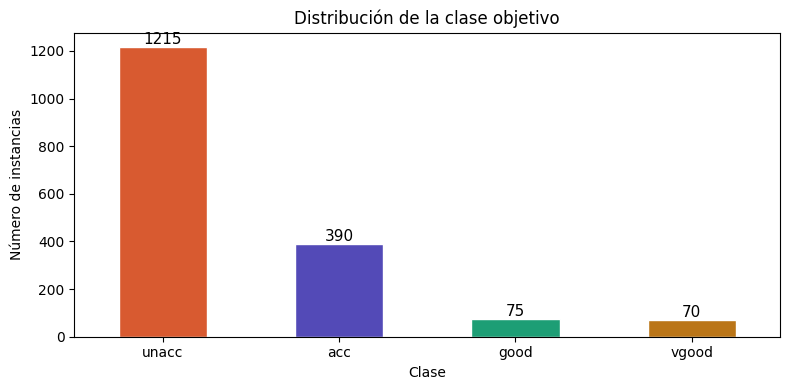

In [26]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 4))

colores = ['#D85A30', '#534AB7', '#1D9E75', '#BA7517']
df['class'].value_counts().plot(
    kind='bar', 
    ax=ax, 
    color=colores,
    edgecolor='white'
)

ax.set_title('Distribución de la clase objetivo')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de instancias')
ax.tick_params(axis='x', rotation=0)

# Añade el número exacto encima de cada barra
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

En un par de párrafos haga un resumen de los principales hallazagos encontrados:    

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [27]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación. Ej.One hot enconding

## División del dataset en datos de entrenamiento y datos de test 

In [28]:
#Código que realice la división en entrenamiento y test, de acuerdo con la estretgia de evluación planeada. Describa cuál es.

## Ajuste de los modelos de clasificación propuestos

Justifique la selección de las dos propuestas de modelación seleccionadas:

In [29]:
#Código de ajuste del modelo de clasificación 1

In [30]:
#Código de ajuste del modelo de clasificación 2

## Evaluación de cada modelo

Al menos incluya:

+ Instancias clasificadas correctamente
+ Instancias clasificadas incorrectamente
+ TP Rate
+ FP Rate
+ Matriz de confusión


In [31]:
#Código para mostrar la evaluación del modelo de clasificación 1

Construya un párrafo con los principales hallazgos.

In [32]:
#Código  para mostrarla evaluación del modelo de clasificación 2

Construya un párrafo con los principales hallazgos.

## Comparación del desempeño de modelos

In [33]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla

In [34]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica

Construya un párrafo con los principales hallazgos.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Realice en este espacio todo el análsis de resultados final incluyendo: ventajas y desventajas de cada modelo propuesto, Resultados comparados. Conclusiones objetivas y significantes con base a las diferentes métricas escogidas. Recomendaciones de mejora de las propuestas: 